
# YouTube Ad Comments—Cleaning, Sentiment & Emotion Analysis

This is created by Sparsh Giri.
This notebook performs cleaning → sentiment → emotions → summaries → charts → CSV exports.


In [1]:

!pip install --quiet emoji nrclex nltk textblob pandas numpy matplotlib

import nltk
# VADER
nltk.download('vader_lexicon', quiet=True)
# Sentence tokenizer(s)
try:
    nltk.download('punkt', quiet=True)
except Exception:
    pass
# Some environments (newer NLTK) expect punkt_tab
try:
    nltk.download('punkt_tab', quiet=True)
except Exception:
    pass

# TextBlob corpora
try:
    from textblob import download_corpora as tb_corpora
    tb_corpora.download_all()
except Exception as e:
    print("TextBlob corpora download skipped/failed:", e)


[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\brown.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package conll2000 to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\conll2000.zip.
[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\movie_reviews.zip.


In [2]:

import re, warnings
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Optional
import emoji
from nrclex import NRCLex
from nltk.sentiment import SentimentIntensityAnalyzer

warnings.simplefilter("ignore", category=FutureWarning)

DATA_DIR = Path("D:/MBA/SEM- 3/Project")
RAW_CSV = DATA_DIR / "brand_comments_raw.csv"
OUT_MAIN = DATA_DIR / "brand_comments_sentiment.csv"
OUT_SUM_BRAND = DATA_DIR / "summary_brand.csv"
OUT_SUM_SECTOR = DATA_DIR / "summary_sector.csv"
OUT_SUM_EMO = DATA_DIR / "summary_overall_emotions.csv"

def drop_unnamed(df: pd.DataFrame) -> pd.DataFrame:
    return df.loc[:, ~df.columns.str.startswith("Unnamed")]

def remove_emojis(text: str) -> str:
    return emoji.replace_emoji(text or "", replace=" ")

URL_PATTERN = re.compile(r"https?://\S+|www\.\S+", re.IGNORECASE)
AT_PATTERN = re.compile(r"@[A-Za-z0-9_]+")
HASH_PATTERN = re.compile(r"#[A-Za-z0-9_]+")

def clean_text(s: Optional[str]) -> str:
    s = str(s or "")
    s = URL_PATTERN.sub(" ", s)
    s = AT_PATTERN.sub(" ", s)
    s = HASH_PATTERN.sub(" ", s)
    s = remove_emojis(s)
    s = re.sub(r"[^\w\s.,!?'-]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def dominant_emotion(text: str) -> Optional[str]:
    """Return top NRC emotion or NaN. Safe against missing corpora."""
    text = str(text or "").strip()
    if not text:
        return np.nan
    try:
        emo = NRCLex(text)
        scores = emo.raw_emotion_scores
        if not scores:
            return np.nan
        return sorted(scores.items(), key=lambda kv: (-kv[1], kv[0]))[0][0]
    except Exception as e:
        # If TextBlob/NLTK corpora missing, don't break the pipeline
        return np.nan

def sentiment_bucket(compound: float) -> str:
    if compound >= 0.05:
        return "positive"
    elif compound <= -0.05:
        return "negative"
    else:
        return "neutral"


In [3]:

# --- Load data (raw preferred, otherwise existing enriched) ---
if RAW_CSV.exists():
    df = pd.read_csv(RAW_CSV)
else:
    alt = DATA_DIR / "brand_comments_sentiment.csv"
    if alt.exists():
        df = pd.read_csv(alt)
    else:
        raise FileNotFoundError("Could not find 'brand_comments_raw.csv' or existing 'brand_comments_sentiment.csv'.")
df = drop_unnamed(df)
print("Loaded rows:", len(df))
print("Columns:", list(df.columns))


Loaded rows: 1148
Columns: ['brand', 'video_id', 'video_url', 'video_title', 'publish_date', 'channel', 'comment_id', 'author', 'comment_text', 'like_count', 'reply_count', 'published_time', 'is_reply', 'parent_id', 'error']


In [4]:

# --- Robust creation of comment_text_clean ---
priority_cols = [
    "comment_text_clean", "comment_text", "text", "body",
    "message", "content", "comments", "comment"
]

present = [c for c in priority_cols if c in df.columns]
text_source = None  # always defined

if present:
    base = present[0]
    text_source = base
    if base == "comment_text_clean":
        df["comment_text_clean"] = df["comment_text_clean"].astype(str).apply(clean_text)
    else:
        df["comment_text_clean"] = df[base].astype(str).apply(clean_text)
else:
    # Heuristic: pick first string-like column with mean length >= 10
    for c in df.columns:
        if pd.api.types.is_object_dtype(df[c]) or pd.api.types.is_string_dtype(df[c]):
            try:
                if df[c].notna().any():
                    lens = df[c].astype(str).str.len()
                    if lens.mean() >= 10:
                        text_source = c
                        break
            except Exception:
                continue
    if text_source is None:
        # Fallback: first column
        text_source = df.columns[0]
        print(f"⚠️ WARNING: No obvious text column found. Falling back to column '{text_source}'.")
    df["comment_text_clean"] = df[text_source].astype(str).apply(clean_text)

print(f"✅ Using column '{text_source}' to build 'comment_text_clean'")


✅ Using column 'comment_text' to build 'comment_text_clean'


In [5]:

# --- Sentiment (VADER) ---
sia = SentimentIntensityAnalyzer()
scores = df["comment_text_clean"].astype(str).apply(sia.polarity_scores)
df["sentiment_score"] = scores.apply(lambda d: d.get("compound", 0.0))
df["sentiment_bucket"] = df["sentiment_score"].apply(sentiment_bucket)


In [6]:

# --- Dominant Emotion (NRCLex) ---
df["emotion"] = df["comment_text_clean"].apply(dominant_emotion)
df["emotion"] = df["emotion"].fillna("neutral")


In [7]:

# --- Save enriched main CSV ---
df = drop_unnamed(df)
df.to_csv(OUT_MAIN, index=False)
print("Saved:", OUT_MAIN)


Saved: D:\MBA\SEM- 3\Project\brand_comments_sentiment.csv


In [8]:

# --- Summary by brand (fallback to channel) ---
brand_like_col = None
for c in ["brand", "Brand", "channel", "Channel"]:
    if c in df.columns:
        brand_like_col = c
        break

if brand_like_col is None:
    tmp = pd.DataFrame({
        "brand": ["ALL"],
        "comments": [len(df)],
        "avg_sentiment": [round(df["sentiment_score"].mean(), 4) if len(df) else 0.0],
        "pct_positive": [round((df["sentiment_bucket"].eq('positive').mean()*100), 2) if len(df) else 0.0],
        "pct_negative": [round((df["sentiment_bucket"].eq('negative').mean()*100), 2) if len(df) else 0.0],
    })
else:
    g = df.groupby(brand_like_col, dropna=False)
    tmp = pd.DataFrame({
        "brand": g.size().index.astype(str),
        "comments": g.size().values,
        "avg_sentiment": g["sentiment_score"].mean().round(4).values,
        "pct_positive": (g["sentiment_bucket"].apply(lambda s: (s=='positive').mean()*100)).round(2).values,
        "pct_negative": (g["sentiment_bucket"].apply(lambda s: (s=='negative').mean()*100)).round(2).values,
    })

tmp = tmp.sort_values(["avg_sentiment","comments"], ascending=[False,False]).reset_index(drop=True)
tmp.to_csv(OUT_SUM_BRAND, index=False)
print("Saved:", OUT_SUM_BRAND)


Saved: D:\MBA\SEM- 3\Project\summary_brand.csv


In [9]:

# --- Summary by sector (if available) ---
if "sector" in df.columns:
    g = df.groupby("sector", dropna=False)
    sec = pd.DataFrame({
        "sector": g.size().index.astype(str),
        "comments": g.size().values,
        "avg_sentiment": g["sentiment_score"].mean().round(4).values,
        "pct_positive": (g["sentiment_bucket"].apply(lambda s: (s=='positive').mean()*100)).round(2).values,
        "pct_negative": (g["sentiment_bucket"].apply(lambda s: (s=='negative').mean()*100)).round(2).values,
    }).sort_values(["avg_sentiment","comments"], ascending=[False,False]).reset_index(drop=True)
    sec.to_csv(OUT_SUM_SECTOR, index=False)
    print("Saved:", OUT_SUM_SECTOR)
else:
    print("No 'sector' column found — skipping sector summary.")


No 'sector' column found — skipping sector summary.


In [10]:

# --- Overall emotions ---
overall = (
    df["emotion"]
    .value_counts(dropna=False)
    .rename_axis("emotion")
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
overall.to_csv(OUT_SUM_EMO, index=False)
print("Saved:", OUT_SUM_EMO)


Saved: D:\MBA\SEM- 3\Project\summary_overall_emotions.csv


In [11]:

print("Rows:", len(df))
print("Sentiment buckets:", df["sentiment_bucket"].value_counts(dropna=False).to_dict())
print("Top emotions:", overall.head(5).to_dict("records"))


Rows: 1148
Sentiment buckets: {'neutral': 574, 'positive': 449, 'negative': 125}
Top emotions: [{'emotion': 'neutral', 'count': 627}, {'emotion': 'positive', 'count': 175}, {'emotion': 'anticipation', 'count': 129}, {'emotion': 'negative', 'count': 65}, {'emotion': 'joy', 'count': 42}]


In [13]:
import matplotlib.pyplot as plt

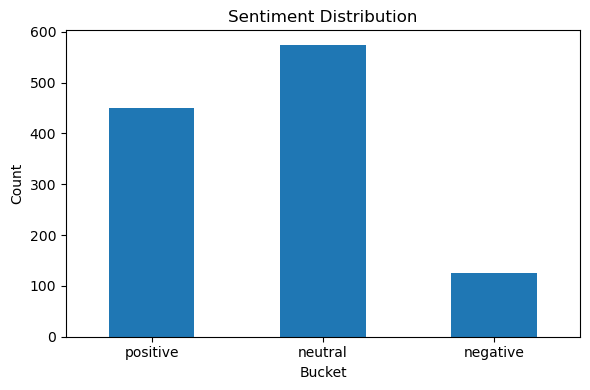

In [19]:
# Sentiment bucket bar chart
if "sentiment_bucket" in df.columns:
    counts = df["sentiment_bucket"].value_counts().reindex(["positive","neutral","negative"]).fillna(0)
    plt.figure(figsize=(6,4))
    counts.plot(kind="bar")
    plt.title("Sentiment Distribution")
    plt.xlabel("Bucket")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig("D:/MBA/SEM- 3/Project/sentiment_bucket.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Skipping: 'sentiment_bucket' not found.")


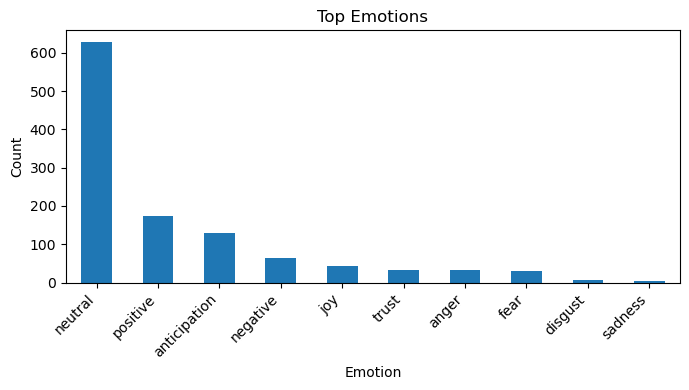

In [20]:
# Emotion bar chart (top 10)
if "emotion" in df.columns:
    emo_counts = df["emotion"].value_counts().head(10)
    plt.figure(figsize=(7,4))
    emo_counts.plot(kind="bar")
    plt.title("Top Emotions")
    plt.xlabel("Emotion")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("D:/MBA/SEM- 3/Project/emotion.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Skipping: 'emotion' not found.")


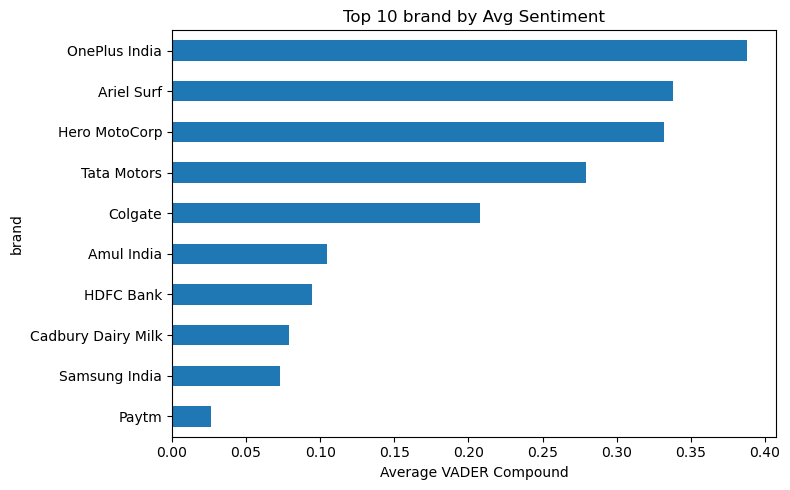

In [21]:
# Barh of average sentiment by brand/channel
brand_like_col = None
for c in ["brand", "Brand", "channel", "Channel"]:
    if c in df.columns:
        brand_like_col = c
        break

if brand_like_col and "sentiment_score" in df.columns:
    g = df.groupby(brand_like_col, dropna=False)["sentiment_score"].mean().sort_values(ascending=False).head(10)
    plt.figure(figsize=(8,5))
    g.iloc[::-1].plot(kind="barh")  # reverse for nicest order top-to-bottom
    plt.title(f"Top {len(g)} {brand_like_col} by Avg Sentiment")
    plt.xlabel("Average VADER Compound")
    plt.ylabel(brand_like_col)
    plt.tight_layout()
    plt.savefig("D:/MBA/SEM- 3/Project/brand_channel.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Skipping: brand/channel column or 'sentiment_score' not found.")


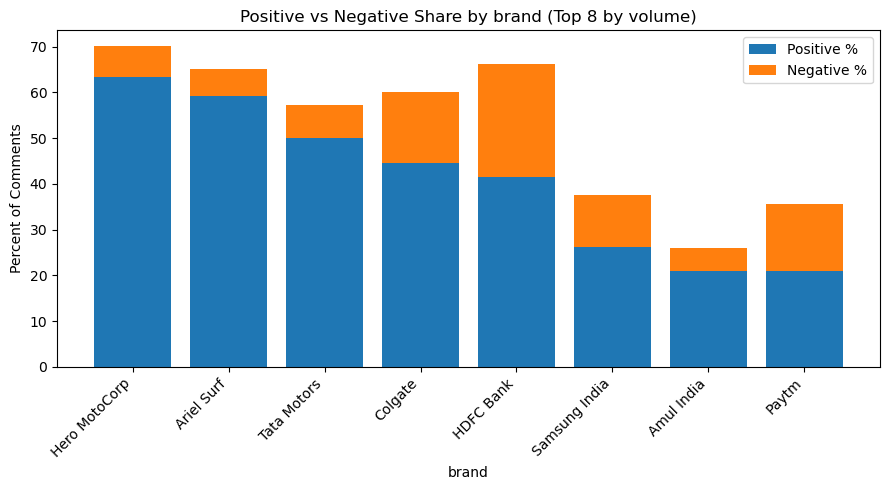

In [22]:
# Stacked bar: positive vs negative % by brand/channel (top N by volume)
brand_like_col = None
for c in ["brand", "Brand", "channel", "Channel"]:
    if c in df.columns:
        brand_like_col = c
        break

if brand_like_col and "sentiment_bucket" in df.columns:
    topN = 8  # adjust if you want more/less
    base = df.copy()
    base["_pos"] = (base["sentiment_bucket"] == "positive").astype(int)
    base["_neg"] = (base["sentiment_bucket"] == "negative").astype(int)

    counts = base.groupby(brand_like_col).size().rename("n")
    top_entities = counts.sort_values(ascending=False).head(topN).index
    sub = base[base[brand_like_col].isin(top_entities)]

    grp = sub.groupby(brand_like_col).agg(
        n=("sentiment_bucket","size"),
        pos=("_pos","sum"),
        neg=("_neg","sum")
    )
    grp["pos_pct"] = (grp["pos"]/grp["n"]*100).round(2)
    grp["neg_pct"] = (grp["neg"]/grp["n"]*100).round(2)

    # Plot stacked
    order = grp.sort_values("pos_pct", ascending=False).index
    plt.figure(figsize=(9,5))
    plt.bar(order, grp.loc[order,"pos_pct"], label="Positive %")
    plt.bar(order, grp.loc[order,"neg_pct"], bottom=grp.loc[order,"pos_pct"], label="Negative %")
    plt.title(f"Positive vs Negative Share by {brand_like_col} (Top {topN} by volume)")
    plt.ylabel("Percent of Comments")
    plt.xlabel(brand_like_col)
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.savefig("D:/MBA/SEM- 3/Project/Stacked bar.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Skipping: brand/channel column or 'sentiment_bucket' not found.")


In [23]:
# Time-series: mean sentiment by day (or week if data is sparse)
if "published_time" in df.columns and "sentiment_score" in df.columns:
    ts = df.copy()
    ts["published_time"] = pd.to_datetime(ts["published_time"], errors="coerce", utc=True)
    ts = ts.dropna(subset=["published_time"])
    if len(ts) > 0:
        # Daily
        daily = ts.set_index("published_time").resample("D")["sentiment_score"].mean()
        plt.figure(figsize=(9,4))
        daily.plot()
        plt.title("Average Sentiment Over Time (Daily)")
        plt.xlabel("Date")
        plt.ylabel("Average VADER Compound")
        plt.tight_layout()
        plt.show()

        # Weekly
        weekly = ts.set_index("published_time").resample("W")["sentiment_score"].mean()
        plt.figure(figsize=(9,4))
        weekly.plot()
        plt.title("Average Sentiment Over Time (Weekly)")
        plt.xlabel("Week")
        plt.ylabel("Average VADER Compound")
        plt.tight_layout()
        plt.show()
    else:
        print("Skipping: no valid datetimes in 'published_time'.")
else:
    print("Skipping: 'published_time' or 'sentiment_score' not found.")


Skipping: no valid datetimes in 'published_time'.


C:\Users\Admin\AppData\Local\Temp\ipykernel_16016\4074577424.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ts["published_time"] = pd.to_datetime(ts["published_time"], errors="coerce", utc=True)
